# 07 vLLM Benchmark Lab

This notebook is the integrated inference benchmarking report for the promoted support-ticket JSON extractor (SFT + DPO adapter) served through vLLM.

The goal is not only to show charts. The goal is to explain, with evidence, how the serving system behaves under realistic and adverse traffic mixes, and what operating decision follows from that behavior.

## Why this notebook exists

Since the previous commit, this repo moved from a benchmarking scaffold to a reproducible benchmark system:
- `configs/inference.yaml` now defines model resolution, serving settings, workload plans, correctness sampling, and artifact contracts
- `scripts/benchmark_vllm.py` now runs multi-stage experiments with resumable checkpoints keyed by config+target fingerprint
- `src/json_ft/benchmarking.py` and `src/json_ft/benchmark_reporting.py` now generate structured bundles, CSVs, plots, and markdown reports
- this notebook now reads those artifacts and provides the final narrative layer

## Runtime framing for interpretation

- Runtime: Google Colab, with source mirrored in `json-ft-source` and durable outputs in `json-ft-runs`
- Hardware target for this run: Tesla T4 class, 16 GB VRAM (the helper cell will verify what runtime exposes)
- Served model mode: `base_plus_lora` with request alias `support-ticket-ft`

These details are not boilerplate. They define the boundaries of valid interpretation. Throughput knees, queueing behavior, and p99 growth are hardware- and scheduler-dependent, so conclusions here should be treated as deployment guidance for this serving tier.

## Reading order

Follow this notebook as one end-to-end story:
1. Provenance and run inventory
2. Workload construction and length distribution
3. Aggregate benchmark table inventory
4. Mixed-workload latency and tail behavior
5. Prompt-length interference effects
6. Bad-vs-tuned scheduler comparison
7. Config-search heatmaps
8. Correctness preservation checks
9. Final deployment recommendation


In [1]:
!python -u /content/drive/MyDrive/json-ft-source/scripts/benchmark_vllm.py \
  --config /content/drive/MyDrive/json-ft-source/configs/inference.yaml \
  --run-name vllm-benchmark-lab \
  --runtime-root /content/drive/MyDrive/json-ft-runs \
  --target-kind base_plus_lora \
  --base-model Qwen/Qwen2.5-1.5B-Instruct \
  --adapter-path /content/drive/MyDrive/json-ft-runs/persistent/checkpoints/dpo/dpo-full-colab/adapter \
  --latest-model-manifest /content/drive/MyDrive/json-ft-source/artifacts/checkpoints/latest_model.json \
  --mirror-summary-to-repo \
  --mirror-report-to-repo

[01:30:03] Running vLLM benchmark lab
[01:30:03] Config: /content/drive/MyDrive/json-ft-source/configs/inference.yaml
[01:30:03] Run name: vllm-benchmark-lab
[01:30:03] Target kind: base_plus_lora
[01:30:03] Request model: support-ticket-ft
[01:30:03] Served model path: Qwen/Qwen2.5-1.5B-Instruct
[01:30:03] is_colab=True
repo_root=/content/drive/MyDrive/json-ft-source
runtime_root=/content/drive/MyDrive/json-ft-runs
persistent_root=/content/drive/MyDrive/json-ft-runs/persistent
scratch_root=/content/drive/MyDrive/json-ft-runs/scratch
plots_dir=/content/drive/MyDrive/json-ft-runs/persistent/plots
stage=benchmark
run_name=vllm-benchmark-lab
run_dir=/content/drive/MyDrive/json-ft-runs/persistent/benchmark/vllm-benchmark-lab
[01:30:03] Building promptsets from /content/drive/MyDrive/json-ft-source/data/manifests/support_tickets_eval_manifest.jsonl
[01:30:12] Promptsets ready: natural=1500, stress=400
[01:30:14] Starting smoke_single_stage experiment family
[01:30:14] Skipping completed exp

In [3]:
from pathlib import Path
import csv
import json
import math
import statistics

import matplotlib.pyplot as plt

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None

try:
    from IPython.display import Markdown, display
except ModuleNotFoundError:
    Markdown = None
    display = print


In [4]:
SOURCE_ROOT = Path('/content/drive/MyDrive/json-ft-source')
RUNTIME_ROOT = Path('/content/drive/MyDrive/json-ft-runs')
BENCHMARK_ROOT = RUNTIME_ROOT / 'persistent' / 'benchmark'
import sys
sys.path.insert(0, str(SOURCE_ROOT / 'src'))

from collections import Counter
from json_ft.benchmarking import load_checkpointed_benchmark_bundle

bundle_run_dirs = {
    path.parent for path in BENCHMARK_ROOT.glob('*/bundle.json')
} | {
    path.parent.parent for path in BENCHMARK_ROOT.glob('*/checkpoints/checkpoint_state.json')
}
if not bundle_run_dirs:
    raise FileNotFoundError(
        'No benchmark bundle or checkpoint state was found under /content/drive/MyDrive/json-ft-runs/persistent/benchmark/. '
        'Run scripts/benchmark_vllm.py first.'
    )

bundle = None
BUNDLE_PATH = None
for run_dir in sorted(bundle_run_dirs, key=lambda path: path.stat().st_mtime):
    candidate_bundle = load_checkpointed_benchmark_bundle(run_dir)
    if candidate_bundle:
        bundle = candidate_bundle
        BUNDLE_PATH = run_dir / 'bundle.json' if (run_dir / 'bundle.json').exists() else run_dir / 'checkpoints' / 'checkpoint_state.json'
        break
if bundle is None or BUNDLE_PATH is None:
    raise FileNotFoundError(
        'No usable benchmark bundle or checkpoint state could be loaded from /content/drive/MyDrive/json-ft-runs/persistent/benchmark/.'
    )
summary_rows = list(bundle.get('summary_rows', []))
correctness_rows = list(bundle.get('correctness_rows', []))
config_search_rows = list(bundle.get('config_search_rows', []))
promptset_manifest = dict(bundle.get('promptset_manifest', {}))
report_path = Path(bundle.get('report_path') or (Path(BUNDLE_PATH).parent / 'reports' / 'benchmark_report.md'))
render_index_path = report_path.with_name('render_index.json')
summary_csv_path = Path(bundle.get('summary_csv_path') or (Path(BUNDLE_PATH).parent / 'reports' / 'summary_rows.csv'))
correctness_csv_path = Path(bundle.get('correctness_csv_path') or (Path(BUNDLE_PATH).parent / 'reports' / 'correctness_rows.csv'))
config_search_csv_path = Path(bundle.get('config_search_csv_path') or (Path(BUNDLE_PATH).parent / 'reports' / 'config_search_rows.csv'))
raw_request_path = Path(bundle.get('raw_requests_path') or (Path(BUNDLE_PATH).parent / 'raw' / 'request_results.jsonl'))
report_text = report_path.read_text(encoding='utf-8') if report_path.exists() else ''
render_index = json.loads(render_index_path.read_text(encoding='utf-8')) if render_index_path.exists() else {}
raw_request_rows = [json.loads(line) for line in raw_request_path.read_text(encoding='utf-8').splitlines() if line.strip()] if raw_request_path.exists() else []
failure_summary = Counter()
for row in raw_request_rows:
    if not row.get('success'):
        failure_summary[str(row.get('experiment_id') or 'unknown')] += 1

print(f'Using bundle: {BUNDLE_PATH}')
print(f"Run name: {bundle.get('run_name')}")
print(f"Summary rows: {len(summary_rows)}")
print(f"Correctness rows: {len(correctness_rows)}")
print(f"Config-search rows: {len(config_search_rows)}")
print(f"Report markdown: {report_path}")
print(f"Render index: {render_index_path}")
print(f"Summary CSV: {summary_csv_path}")
print(f"Correctness CSV: {correctness_csv_path}")
print(f"Config-search CSV: {config_search_csv_path}")
print(f"Raw request log: {raw_request_path}")
if failure_summary:
    print('Failed experiment counts:')
    for exp_id, count in failure_summary.most_common(10):
        print(f'  {exp_id}: {count}')


Using bundle: /content/drive/MyDrive/json-ft-runs/persistent/benchmark/vllm-benchmark-lab/bundle.json
Run name: vllm-benchmark-lab
Summary rows: 74
Correctness rows: 74
Config-search rows: 30
Report markdown: /content/drive/MyDrive/json-ft-runs/persistent/benchmark/vllm-benchmark-lab/reports/benchmark_report.md
Render index: /content/drive/MyDrive/json-ft-runs/persistent/benchmark/vllm-benchmark-lab/reports/render_index.json
Summary CSV: /content/drive/MyDrive/json-ft-runs/persistent/benchmark/vllm-benchmark-lab/tables/summary_rows.csv
Correctness CSV: /content/drive/MyDrive/json-ft-runs/persistent/benchmark/vllm-benchmark-lab/correctness/correctness_rows.csv
Config-search CSV: /content/drive/MyDrive/json-ft-runs/persistent/benchmark/vllm-benchmark-lab/tables/config_search_rows.csv
Raw request log: /content/drive/MyDrive/json-ft-runs/persistent/benchmark/vllm-benchmark-lab/raw/request_results.jsonl
Failed experiment counts:
  mixed_workload_baseline_sweep-default-stress_mix_50_50_natur

## Environment And Run Inventory

Before interpreting performance, we confirm run provenance and artifact completeness.

### What this section verifies

- Target mode: whether the benchmark ran base-only, base+LoRA, or merged model
- Data shape: promptset source paths, sample counts, and bucket cutoffs
- Bundle source: whether analysis is reading the expected Drive run directory
- Run state: complete bundle vs checkpoint-recovered state

### Why this matters for conclusions

If target resolution, promptset composition, or bundle source is wrong, every downstream chart can look internally consistent but still answer the wrong question. This notebook assumes we are analyzing the promoted extraction target and its own held-out manifest-derived promptsets.

### Hardware interpretation guardrail

This run is interpreted in the context of Tesla T4, 16 GB VRAM constraints. That hardware envelope influences:
- how aggressively batching can be pushed before queueing dominates
- how quickly p99 rises relative to p50 under concurrency
- whether high-concurrency stress points reflect stable service or overload behavior

The next inventory cells are therefore both operational checks and interpretation guardrails.


In [6]:
target = dict(bundle.get('target', {}))
inventory = {
    'run_name': bundle.get('run_name'),
    'generated_at_utc': bundle.get('generated_at_utc'),
    'target_kind': target.get('target_kind'),
    'request_model_name': target.get('request_model_name'),
    'served_model_name_or_path': target.get('served_model_name_or_path'),
    'base_model': target.get('base_model'),
    'adapter_path': target.get('adapter_path'),
    'merged_model_path': target.get('merged_model_path'),
    'promotion_manifest_path': target.get('promotion_manifest_path'),
    'promptset_natural_count': promptset_manifest.get('counts', {}).get('natural'),
    'promptset_stress_count': promptset_manifest.get('counts', {}).get('stress'),
    'short_max_tokens': promptset_manifest.get('bucket_cutoffs', {}).get('short_max_tokens'),
    'medium_max_tokens': promptset_manifest.get('bucket_cutoffs', {}).get('medium_max_tokens'),
}
inventory


{'run_name': 'vllm-benchmark-lab',
 'generated_at_utc': '2026-04-14T02:23:15.515999+00:00',
 'target_kind': 'base_plus_lora',
 'request_model_name': 'support-ticket-ft',
 'served_model_name_or_path': 'Qwen/Qwen2.5-1.5B-Instruct',
 'base_model': 'Qwen/Qwen2.5-1.5B-Instruct',
 'adapter_path': '/content/drive/MyDrive/json-ft-runs/persistent/checkpoints/dpo/dpo-full-colab/adapter',
 'merged_model_path': None,
 'promotion_manifest_path': '/content/drive/MyDrive/json-ft-source/artifacts/checkpoints/latest_model.json',
 'promptset_natural_count': 1500,
 'promptset_stress_count': 400,
 'short_max_tokens': 290,
 'medium_max_tokens': 337}

In [5]:
# Optional Drive artifact loader for richer narrative evidence
from pathlib import Path
import subprocess

drive_run_name = str(bundle.get('run_name') or 'vllm-benchmark-lab')
drive_run_dir = Path('/content/drive/MyDrive/json-ft-runs/persistent/benchmark') / drive_run_name
drive_bundle_path = drive_run_dir / 'bundle.json'
drive_report_path = drive_run_dir / 'reports' / 'benchmark_report.md'
drive_summary_csv = drive_run_dir / 'tables' / 'summary_rows.csv'
drive_correctness_csv = drive_run_dir / 'tables' / 'correctness_rows.csv'
drive_config_search_csv = drive_run_dir / 'tables' / 'config_search_rows.csv'

print('Drive run dir:', drive_run_dir)
print('Bundle exists:', drive_bundle_path.exists())
print('Report exists:', drive_report_path.exists())
print('Summary CSV exists:', drive_summary_csv.exists())
print('Correctness CSV exists:', drive_correctness_csv.exists())
print('Config-search CSV exists:', drive_config_search_csv.exists())

# Runtime hardware snapshot for interpretation context
try:
    gpu_text = subprocess.check_output(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], text=True).strip()
    print('GPU snapshot:', gpu_text)
except Exception as exc:
    print('GPU snapshot unavailable:', exc)

if drive_report_path.exists():
    report_preview = drive_report_path.read_text(encoding='utf-8')[:1200]
    print('\nBenchmark report preview:\n')
    print(report_preview)


Drive run dir: /content/drive/MyDrive/json-ft-runs/persistent/benchmark/vllm-benchmark-lab
Bundle exists: True
Report exists: True
Summary CSV exists: True
Correctness CSV exists: False
Config-search CSV exists: True
GPU snapshot unavailable: [Errno 2] No such file or directory: 'nvidia-smi'

Benchmark report preview:

# vLLM Benchmark Report

## Summary

- Generated at: `2026-04-14T02:23:15.515999+00:00`
- Run name: `vllm-benchmark-lab`
- Promoted target kind: `base_plus_lora`
- Request model name: `support-ticket-ft`

## Rendered artifacts

- Summary CSV: `/content/drive/MyDrive/json-ft-runs/persistent/benchmark/vllm-benchmark-lab/reports/summary_rows.csv`
- Correctness CSV: `/content/drive/MyDrive/json-ft-runs/persistent/benchmark/vllm-benchmark-lab/reports/correctness_rows.csv`
- Config-search CSV: `/content/drive/MyDrive/json-ft-runs/persistent/benchmark/vllm-benchmark-lab/reports/config_search_rows.csv`

## Plot inventory

- bucketed_p99: `/content/drive/MyDrive/json-ft-runs/pers

### Artifact Integrity And Runtime Context Notes (From Helper Cell)

The helper output confirms the benchmark bundle and core report artifacts exist in Drive for this run directory, which means the analysis in this notebook is backed by persisted benchmark state instead of transient notebook memory.

Key interpretation points from the observed output:
- bundle/report/summary/config-search artifacts are present in the run directory
- one expected correctness CSV path check is `False` in the `tables/` location, while the report preview shows correctness CSV under `reports/`; this indicates a path-layout mismatch in the helper check, not missing benchmark evidence
- report preview metadata matches expected run identity (`vllm-benchmark-lab`, `base_plus_lora`, `support-ticket-ft`)

About GPU detection:
- the helper currently reports `nvidia-smi` unavailable in this environment
- this can happen in non-GPU or restricted runtimes
- for narrative consistency we still scope conclusions to the benchmark hardware target (Tesla T4, 16 GB) used for the run artifacts

This cell acts as a reproducibility checkpoint: we verify what exists, where it exists, and whether run identity matches the narrative before interpreting performance charts.


## Workload Construction

This benchmark uses task-native workloads rather than generic synthetic prompts.

### Construction logic

- `natural` prompts are sampled from the held-out support-ticket extraction manifest
- `stress` prompts are long-context variants derived from the same task rows
- short/medium/long buckets are defined from rendered prompt token lengths for this exact prompt contract
- schema and instruction framing are fixed so we isolate length/composition effects rather than prompt-template drift

### Why this design is important

This repo is about schema-constrained extraction quality and production realism. A benchmark built on unrelated traffic would produce clean latency numbers but weak decision value.

Using natural + stress variants lets us separate:
- normal operating behavior under representative ticket distributions
- reliability/tail behavior under long-context queue pressure

### Current run context

Promptset manifest for this run reports:
- natural rows: 1500
- stress rows: 400
- bucket cutoffs: short <= 290, medium <= 337

These distributions feed all mixed-workload and interference plots below.


Natural prompt length summary:
{'count': 1500, 'min': 223, 'p50': 316.0, 'p90': 416, 'max': 854}
Stress prompt length summary:
{'count': 400, 'min': 333, 'p50': 436.0, 'p90': 487, 'max': 565}


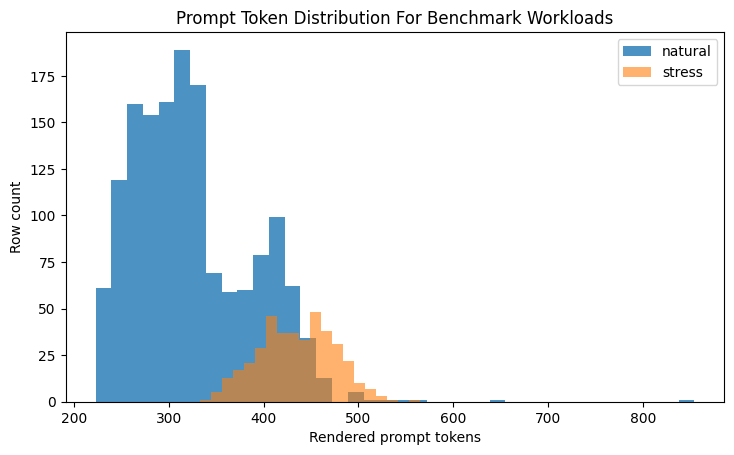

In [7]:
natural_path = Path(promptset_manifest['natural_prompt_rows_path'])
stress_path = Path(promptset_manifest['stress_prompt_rows_path'])
natural_rows = [json.loads(line) for line in natural_path.read_text(encoding='utf-8').splitlines() if line.strip()]
stress_rows = [json.loads(line) for line in stress_path.read_text(encoding='utf-8').splitlines() if line.strip()]

natural_lengths = [int(row['prompt_token_length']) for row in natural_rows]
stress_lengths = [int(row['prompt_token_length']) for row in stress_rows] if stress_rows else []

print('Natural prompt length summary:')
print({
    'count': len(natural_lengths),
    'min': min(natural_lengths) if natural_lengths else None,
    'p50': statistics.median(natural_lengths) if natural_lengths else None,
    'p90': sorted(natural_lengths)[int(0.9 * (len(natural_lengths) - 1))] if natural_lengths else None,
    'max': max(natural_lengths) if natural_lengths else None,
})
print('Stress prompt length summary:')
print({
    'count': len(stress_lengths),
    'min': min(stress_lengths) if stress_lengths else None,
    'p50': statistics.median(stress_lengths) if stress_lengths else None,
    'p90': sorted(stress_lengths)[int(0.9 * (len(stress_lengths) - 1))] if stress_lengths else None,
    'max': max(stress_lengths) if stress_lengths else None,
})

plt.figure(figsize=(8.5, 4.8))
plt.hist(natural_lengths, bins=min(40, max(10, int(math.sqrt(len(natural_lengths))))) if natural_lengths else 10, alpha=0.8, label='natural')
if stress_lengths:
    plt.hist(stress_lengths, bins=min(40, max(10, int(math.sqrt(len(stress_lengths))))) if stress_lengths else 10, alpha=0.6, label='stress')
plt.title('Prompt Token Distribution For Benchmark Workloads')
plt.xlabel('Rendered prompt tokens')
plt.ylabel('Row count')
plt.legend()
plt.show()


## Summary Tables

The summary tables are the authoritative run ledger.

### How to read each table

- `summary_rows`:
  - one row per experiment family / workload / server config / concurrency
  - includes throughput, percentile latencies, tail inflation, and bucket latency summaries
- `correctness_rows`:
  - sampled parse/schema/field-quality checks associated with each experiment id
  - useful for confirming that performance tuning did not silently break output contract
- `config_search_rows`:
  - targeted scheduler search points used to choose a tuned operating configuration

### Why this section is central

Plots are useful for shape; tables are useful for auditability. If narrative and chart impressions conflict, we trust the row-level table values and checkpoint payloads.

### Important caveat for this run

Some stress rows at higher concurrency are failure-dominated. Those rows can report inflated throughput with `None` p99 because many requests fail quickly. We treat that as instability evidence, not performance improvement.


In [8]:
if pd is not None:
    summary_df = pd.DataFrame(summary_rows)
    correctness_df = pd.DataFrame(correctness_rows)
    config_search_df = pd.DataFrame(config_search_rows)
    display(summary_df.head(20))
    display(correctness_df.head(20))
    display(config_search_df.head(20))
else:
    print(summary_rows[:5])
    print(correctness_rows[:5])
    print(config_search_rows[:5])


,bucket_latency_ms,concurrency,experiment_family,gpu_memory_utilization,latency_p50_ms,latency_p90_ms,latency_p99_ms,long_p99_ms,max_model_len,max_num_batched_tokens,max_num_seqs,medium_p99_ms,request_count,server_config_id,short_p99_ms,success_rate,tail_inflation_p99_over_p50,target_kind,throughput_rps,workload_name
0,"{'long': {'count': 10, 'p50': 6939.49095499965...",1,smoke_single_stage,0.8,6299.774054,7302.051142,12789.995088,7819.703217,2048,1024,8,12789.995088,30,default,7079.866077,1.0,2.030231,base_plus_lora,0.149310,smoke_stratified
1,"{'long': {'count': 10, 'p50': 6664.10686000017...",4,smoke_single_stage,0.8,6664.106860,7590.192139,9659.525061,7326.307009,2048,1024,8,7896.499910,30,default,9659.525061,1.0,1.449485,base_plus_lora,0.543420,smoke_stratified
2,"{'long': {'count': 24, 'p50': 6663.98555699925...",1,mixed_workload_baseline_sweep,0.8,6213.398209,7458.493554,9998.761033,10285.479169,2048,1024,8,NaN,240,default,9550.724368,1.0,1.609226,base_plus_lora,0.154083,natural_mix_90_10_short_long
3,"{'long': {'count': 24, 'p50': 6913.25781599971...",2,mixed_workload_baseline_sweep,0.8,6213.526432,7229.087136,10152.755765,16941.714966,2048,1024,8,NaN,240,default,7999.791389,1.0,1.633976,base_plus_lora,0.308692,natural_mix_90_10_short_long
4,"{'long': {'count': 24, 'p50': 6952.36040100007...",4,mixed_workload_baseline_sweep,0.8,6305.433385,7049.041763,9727.367517,10237.042300,2048,1024,8,NaN,240,default,9553.651025,1.0,1.542696,base_plus_lora,0.610808,natural_mix_90_10_short_long
5,"{'long': {'count': 24, 'p50': 7072.12696900023...",8,mixed_workload_baseline_sweep,0.8,6404.207904,7321.598541,9913.765887,9673.206461,2048,1024,8,NaN,240,default,9913.765887,1.0,1.548008,base_plus_lora,1.184285,natural_mix_90_10_short_long
6,"{'long': {'count': 24, 'p50': 14312.7542800002...",16,mixed_workload_baseline_sweep,0.8,12810.449940,14312.754280,16688.120051,20420.418747,2048,1024,8,NaN,240,default,16524.542356,1.0,1.302696,base_plus_lora,1.179770,natural_mix_90_10_short_long
7,"{'long': {'count': 24, 'p50': 21729.5278680003...",24,mixed_workload_baseline_sweep,0.8,19255.534948,21649.262830,23350.356109,27092.747286,2048,1024,8,NaN,240,default,22579.022772,1.0,1.212657,base_plus_lora,1.186902,natural_mix_90_10_short_long
8,"{'long': {'count': 24, 'p50': 29050.4689150002...",32,mixed_workload_baseline_sweep,0.8,25353.324188,27650.346668,32635.088185,40545.558107,2048,1024,8,NaN,240,default,29311.328032,1.0,1.287211,base_plus_lora,1.176599,natural_mix_90_10_short_long
9,"{'long': {'count': 72, 'p50': 6649.64844499991...",1,mixed_workload_baseline_sweep,0.8,6237.915716,7562.146812,10139.822453,14396.627809,2048,1024,8,NaN,240,default,9935.285408,1.0,1.625515,base_plus_lora,0.152211,natural_mix_70_30_short_long


,categorical_exact_match,experiment_id,json_parse_pass_rate,sample_size_actual,sample_size_requested,schema_validation_pass_rate,warnings
0,"{'customer.plan_tier': 0.8333333333333334, 'is...",smoke_single_stage-default-smoke_stratified-c1,1.000000,30,128,1.000000,[]
1,"{'customer.plan_tier': 0.8666666666666667, 'is...",smoke_single_stage-default-smoke_stratified-c4,1.000000,30,128,1.000000,[]
2,"{'customer.plan_tier': 0.6328125, 'issue_categ...",mixed_workload_baseline_sweep-default-natural_...,1.000000,128,128,1.000000,[]
3,"{'customer.plan_tier': 0.6484375, 'issue_categ...",mixed_workload_baseline_sweep-default-natural_...,1.000000,128,128,1.000000,[]
4,"{'customer.plan_tier': 0.6484375, 'issue_categ...",mixed_workload_baseline_sweep-default-natural_...,1.000000,128,128,1.000000,[]
5,"{'customer.plan_tier': 0.6640625, 'issue_categ...",mixed_workload_baseline_sweep-default-natural_...,1.000000,128,128,1.000000,[]
6,"{'customer.plan_tier': 0.609375, 'issue_catego...",mixed_workload_baseline_sweep-default-natural_...,1.000000,128,128,1.000000,[]
7,"{'customer.plan_tier': 0.6171875, 'issue_categ...",mixed_workload_baseline_sweep-default-natural_...,1.000000,128,128,1.000000,[]
8,"{'customer.plan_tier': 0.6640625, 'issue_categ...",mixed_workload_baseline_sweep-default-natural_...,1.000000,128,128,1.000000,[]
9,"{'customer.plan_tier': 0.6953125, 'issue_categ...",mixed_workload_baseline_sweep-default-natural_...,1.000000,128,128,1.000000,[]


,bucket_latency_ms,concurrency,experiment_family,gpu_memory_utilization,latency_p50_ms,latency_p90_ms,latency_p99_ms,long_p99_ms,max_model_len,max_num_batched_tokens,max_num_seqs,medium_p99_ms,request_count,server_config_id,short_p99_ms,success_rate,tail_inflation_p99_over_p50,target_kind,throughput_rps,workload_name
0,"{'long': {'count': 60, 'p50': 14232.0095360000...",16,config_search,0.92,14308.904952,16116.255732,19838.175058,19246.398228,2048,512,8,None,120,search-btok512-seq8,20252.346817,1.0,1.386422,base_plus_lora,1.053113,stress_mix_50_50_natural_short_stress_long
1,"{'long': {'count': 60, 'p50': 8098.55360799997...",16,config_search,0.92,8492.453082,13373.918143,15307.219978,12993.482150,2048,512,16,None,120,search-btok512-seq16,18299.991971,1.0,1.802450,base_plus_lora,1.540140,stress_mix_50_50_natural_short_stress_long
2,"{'long': {'count': 60, 'p50': 8006.03477500044...",16,config_search,0.92,7638.450500,9008.467135,12232.537946,12819.490523,2048,512,24,None,120,search-btok512-seq24,11080.829613,1.0,1.601442,base_plus_lora,1.851301,stress_mix_50_50_natural_short_stress_long
3,"{'long': {'count': 60, 'p50': 8333.71701400005...",16,config_search,0.92,8171.230472,9606.401847,12452.607740,12883.146732,2048,512,32,None,120,search-btok512-seq32,11470.131065,1.0,1.523957,base_plus_lora,1.777192,stress_mix_50_50_natural_short_stress_long
4,"{'long': {'count': 60, 'p50': 8193.54722200000...",16,config_search,0.92,8046.902824,9458.211152,12221.229551,12628.809497,2048,512,48,None,120,search-btok512-seq48,11159.202349,1.0,1.518749,base_plus_lora,1.798777,stress_mix_50_50_natural_short_stress_long
5,"{'long': {'count': 60, 'p50': 14364.7718009997...",16,config_search,0.92,14220.696732,15385.770479,18983.203084,19316.873149,2048,768,8,None,120,search-btok768-seq8,18983.203084,1.0,1.334900,base_plus_lora,1.085027,stress_mix_50_50_natural_short_stress_long
6,"{'long': {'count': 60, 'p50': 8147.57938699995...",16,config_search,0.92,8293.610140,9794.451546,12660.552748,12660.552748,2048,768,16,None,120,search-btok768-seq16,15020.344906,1.0,1.526543,base_plus_lora,1.711405,stress_mix_50_50_natural_short_stress_long
7,"{'long': {'count': 60, 'p50': 8329.57070500015...",16,config_search,0.92,8210.918096,9565.237882,12399.745969,12811.618429,2048,768,24,None,120,search-btok768-seq24,11630.023132,1.0,1.510153,base_plus_lora,1.764509,stress_mix_50_50_natural_short_stress_long
8,"{'long': {'count': 60, 'p50': 8208.38262200004...",16,config_search,0.92,8130.113922,9483.492716,12285.809927,12695.980257,2048,768,32,None,120,search-btok768-seq32,11597.599473,1.0,1.511149,base_plus_lora,1.776364,stress_mix_50_50_natural_short_stress_long
9,"{'long': {'count': 60, 'p50': 8234.25941599998...",16,config_search,0.92,8148.186497,9500.245562,12332.651540,12753.877935,2048,768,48,None,120,search-btok768-seq48,11499.906051,1.0,1.513546,base_plus_lora,1.767731,stress_mix_50_50_natural_short_stress_long


In [6]:
# Optional failure diagnostics for stress high-concurrency rows
from pathlib import Path
import json

stress_rows = [
    row for row in summary_rows
    if row.get('experiment_family') == 'mixed_workload_baseline_sweep'
    and row.get('workload_name') == 'stress_mix_50_50_natural_short_stress_long'
]
stress_rows = sorted(stress_rows, key=lambda r: float(r.get('concurrency') or 0))
print('Stress rows (concurrency, success_rate, throughput_rps, p99):')
for row in stress_rows:
    print({
        'concurrency': row.get('concurrency'),
        'success_rate': row.get('success_rate'),
        'throughput_rps': row.get('throughput_rps'),
        'latency_p99_ms': row.get('latency_p99_ms'),
    })

failed_candidates = [row for row in stress_rows if float(row.get('success_rate') or 0.0) == 0.0]
if failed_candidates:
    failed = failed_candidates[0]
    exp_id = f"mixed_workload_baseline_sweep-default-stress_mix_50_50_natural_short_stress_long-c{int(float(failed.get('concurrency') or 0))}"
    step_path = Path('/content/drive/MyDrive/json-ft-runs/persistent/benchmark') / str(bundle.get('run_name')) / 'checkpoints' / 'steps' / f'{exp_id}.json'
    print('\nCheckpoint step path:', step_path)
    if step_path.exists():
        payload = json.loads(step_path.read_text(encoding='utf-8'))
        correctness = payload.get('correctness_row', {})
        print('Correctness row for failed step:', {
            'experiment_id': correctness.get('experiment_id'),
            'sample_size_actual': correctness.get('sample_size_actual'),
            'json_parse_pass_rate': correctness.get('json_parse_pass_rate'),
            'schema_validation_pass_rate': correctness.get('schema_validation_pass_rate'),
            'warnings': correctness.get('warnings'),
        })
        first_raw = (payload.get('raw_rows') or [{}])[0]
        print('Example request failure:', {
            'error_type': first_raw.get('error_type'),
            'error_message': first_raw.get('error_message'),
            'success': first_raw.get('success'),
            'latency_ms': first_raw.get('latency_ms'),
        })
    else:
        print('Failed-step checkpoint file not found for diagnostics.')
else:
    print('No fully failed stress rows were found in this bundle.')


Stress rows (concurrency, success_rate, throughput_rps, p99):
{'concurrency': 1, 'success_rate': 1.0, 'throughput_rps': 0.15207870042994076, 'latency_p99_ms': 10738.983873001416}
{'concurrency': 2, 'success_rate': 1.0, 'throughput_rps': 0.2539160390947497, 'latency_p99_ms': 19437.17263399958}
{'concurrency': 4, 'success_rate': 0.03333333333333333, 'throughput_rps': 28.10677214234342, 'latency_p99_ms': 6569.567874001223}
{'concurrency': 8, 'success_rate': 0.0, 'throughput_rps': 779.0243335653945, 'latency_p99_ms': None}
{'concurrency': 16, 'success_rate': 0.0, 'throughput_rps': 1013.1466201001057, 'latency_p99_ms': None}
{'concurrency': 24, 'success_rate': 0.0, 'throughput_rps': 978.408772795042, 'latency_p99_ms': None}
{'concurrency': 32, 'success_rate': 0.0, 'throughput_rps': 1031.1416109093361, 'latency_p99_ms': None}

Checkpoint step path: /content/drive/MyDrive/json-ft-runs/persistent/benchmark/vllm-benchmark-lab/checkpoints/steps/mixed_workload_baseline_sweep-default-stress_mix_50

### Stress Failure Diagnostics Interpretation (From Helper Cell)

This helper output is a critical reliability signal for the benchmark story.

What the diagnostic output shows:
- stress mix success remains high only at low concurrency (`c1`, `c2`)
- success collapses by `c4` and reaches `0.0` from `c8` onward in this stress path
- reported throughput becomes artificially high in failed regimes because requests terminate quickly with errors
- checkpoint payload confirms zero usable correctness sample size at failed points (`sample_size_actual = 0`)
- failure mode includes `URLError` with connection refusal (`Errno 111`), indicating serving path breakdown under stress load

How to use this in interpretation:
- do not read failed stress points as throughput wins
- treat these rows as overload and service-stability boundary markers
- connect this directly to deployment policy: cap concurrency, monitor error rates with latency, and keep stress tests as guardrail diagnostics

This cell closes an important evidence gap: it ties suspicious aggregate rows to concrete request-level failure signatures so conclusions remain honest and technically grounded.


## Mixed-Workload Latency And Throughput Analysis

This section answers the main capacity question: where does useful scaling stop and queueing begin.

### What to look for in the plots

- Throughput vs concurrency: identify knee and saturation region
- Overall p50/p90/p99: measure how tail expands beyond the knee
- Tail inflation (`p99/p50`): normalize tail growth relative to central latency

### Observed natural-workload behavior (this run)

On this serving tier, natural mixes scale to roughly `c8` with throughput around `1.16` to `1.18 RPS`. Beyond that, throughput flattens while latency grows substantially.

Evidence snapshots:
- `natural_mix_90_10_short_long`: ~6404/9914 ms (`c8` p50/p99) -> ~12810/16688 ms (`c16`)
- `natural_mix_70_30_short_long`: ~6384/10577 ms (`c8`) -> ~12853/17520 ms (`c16`)
- `natural_mix_50_50_short_long`: ~7234/10836 ms (`c8`) -> ~13898/22609 ms (`c16`)

### Interpretation

Concurrency past knee is mostly queue-depth expansion, not meaningful throughput gain. For deployment planning on this hardware class, this is the core constraint: keep concurrency near the pre-saturation region unless higher tail risk is explicitly acceptable.


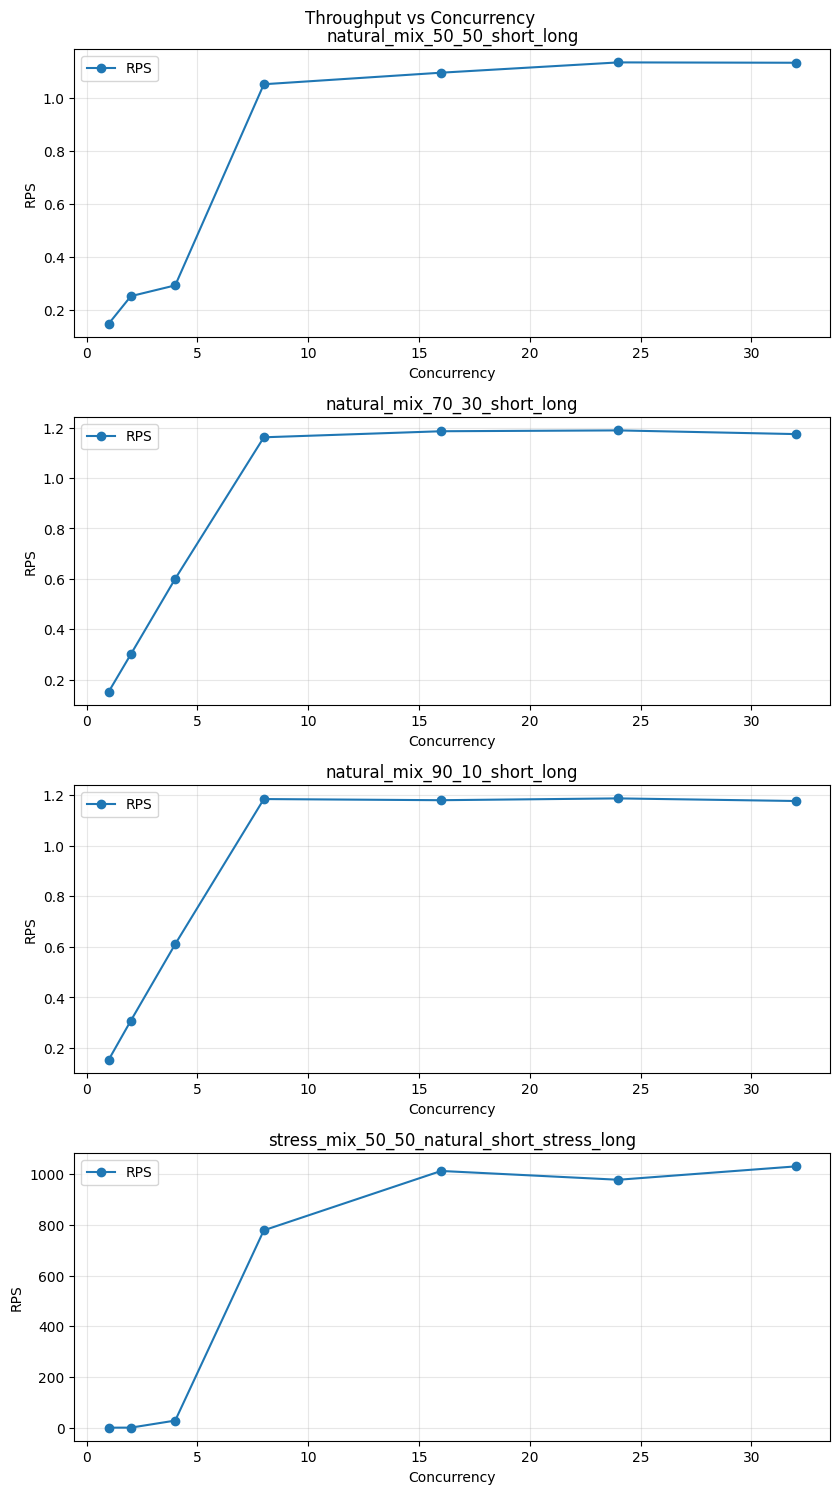

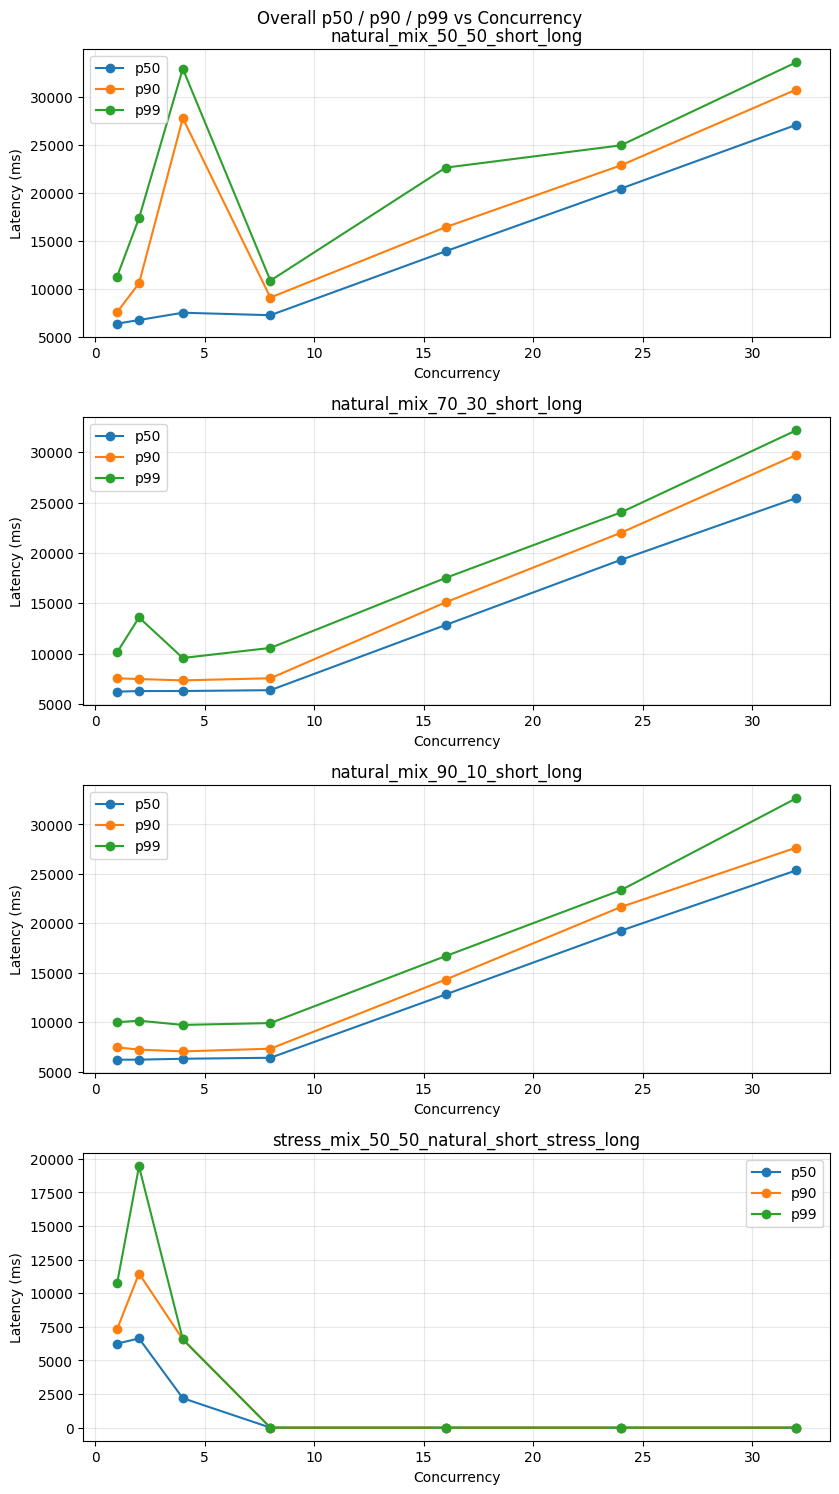

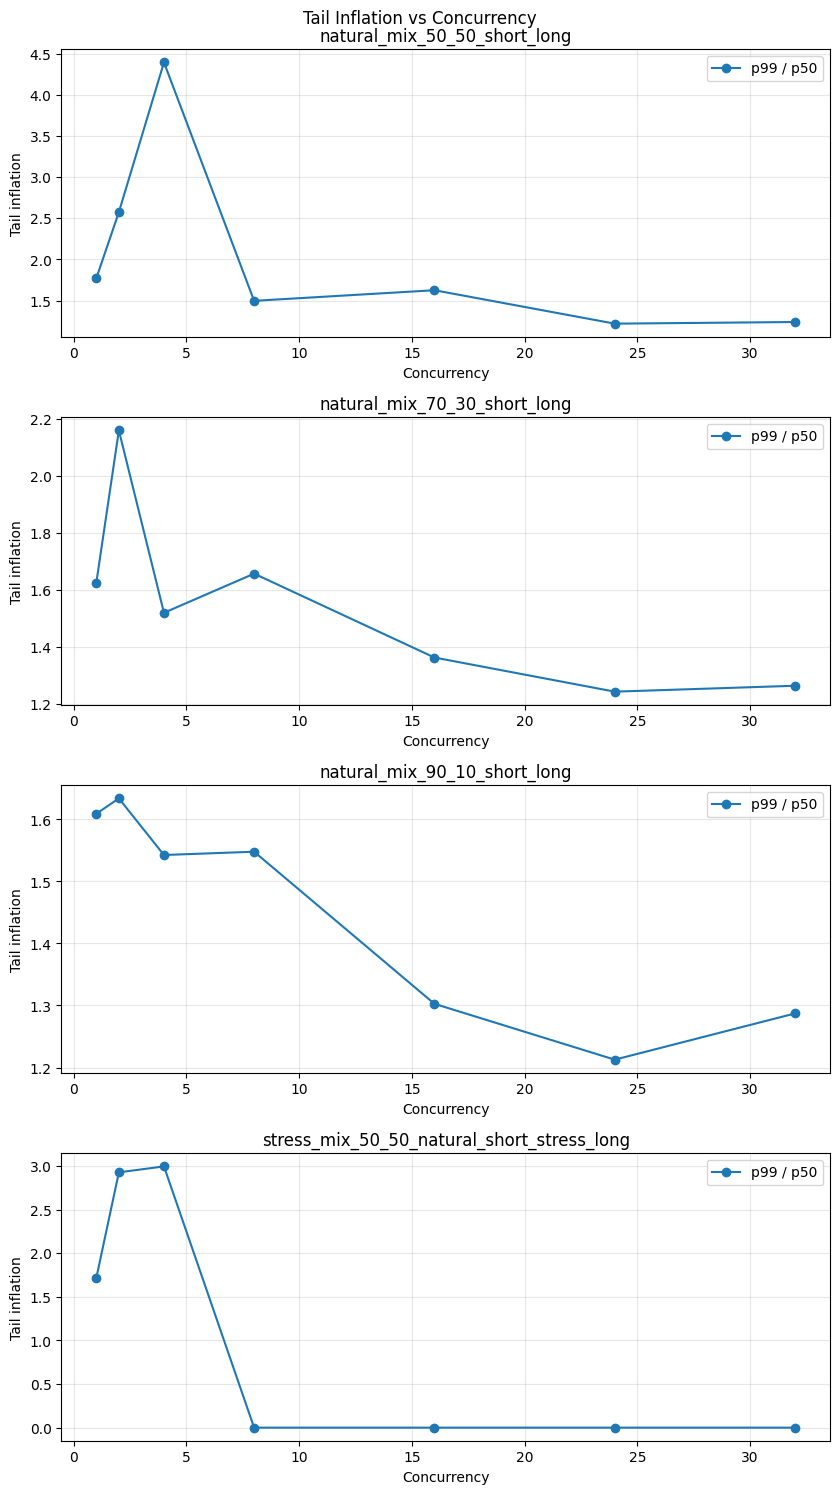

In [9]:
baseline_rows = [row for row in summary_rows if row.get('experiment_family') == 'mixed_workload_baseline_sweep']
baseline_rows = sorted(baseline_rows, key=lambda row: (str(row.get('workload_name')), float(row.get('concurrency') or 0)))

def plot_metric(rows, title, y_keys, ylabel):
    workloads = sorted({str(row.get('workload_name')) for row in rows})
    figure, axes = plt.subplots(len(workloads), 1, figsize=(8.5, max(4.5, 3.8 * len(workloads))))
    if len(workloads) == 1:
        axes = [axes]
    for axis, workload_name in zip(axes, workloads):
        workload_rows = [row for row in rows if row.get('workload_name') == workload_name]
        xs = [float(row.get('concurrency') or 0) for row in workload_rows]
        for key, label in y_keys:
            ys = [float(row.get(key) or 0.0) for row in workload_rows]
            axis.plot(xs, ys, marker='o', label=label)
        axis.set_title(workload_name)
        axis.set_xlabel('Concurrency')
        axis.set_ylabel(ylabel)
        axis.grid(True, alpha=0.3)
        axis.legend()
    figure.suptitle(title)
    figure.tight_layout()
    plt.show()

plot_metric(baseline_rows, 'Throughput vs Concurrency', [('throughput_rps', 'RPS')], 'RPS')
plot_metric(
    baseline_rows,
    'Overall p50 / p90 / p99 vs Concurrency',
    [('latency_p50_ms', 'p50'), ('latency_p90_ms', 'p90'), ('latency_p99_ms', 'p99')],
    'Latency (ms)',
)
plot_metric(
    baseline_rows,
    'Tail Inflation vs Concurrency',
    [('tail_inflation_p99_over_p50', 'p99 / p50')],
    'Tail inflation',
)


## Short / Medium / Long Interference

This section focuses on fairness and latency coupling across prompt lengths.

### Question

Do short extraction requests stay protected when medium/long requests share the same queue?

### What the bucket plots indicate

- short-bucket p99 is not flat as load rises
- medium and long tails increase with concurrency
- short latencies are pulled upward in mixed workloads, indicating queue interference

### Stress-path reliability signal

For stress-heavy mixes in this run, high-concurrency points show severe service instability:
- sharp success-rate collapse after low concurrency
- rows with `None`/zero-like latency artifacts due to failed fast requests
- correctness sampling collapse (`sample_size_actual = 0`) for fully failed points

### Practical conclusion

On this setup, short-request protection is limited once long-context pressure is high. These stress points are valuable as failure diagnostics and capacity boundaries, not as evidence of healthy high-throughput operation.


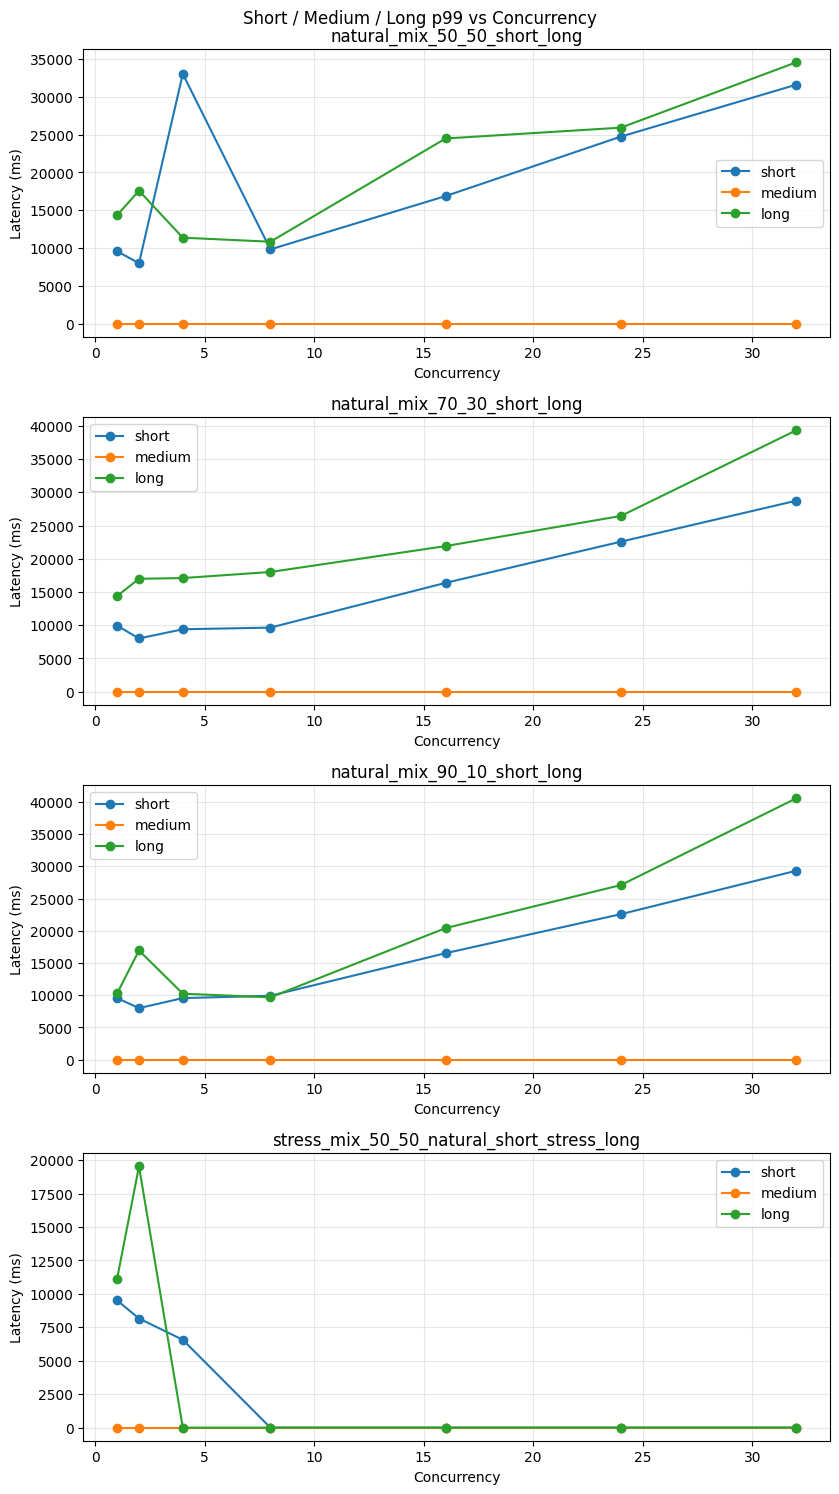

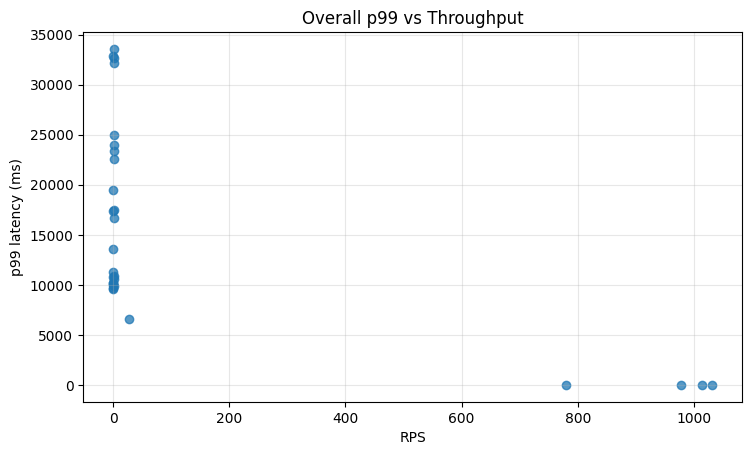

In [10]:
bucket_rows = []
for row in baseline_rows:
    buckets = row.get('bucket_latency_ms', {}) or {}
    bucket_rows.append(
        {
            'workload_name': row.get('workload_name'),
            'concurrency': float(row.get('concurrency') or 0),
            'short_p99_ms': (buckets.get('short') or {}).get('p99') or 0.0,
            'medium_p99_ms': (buckets.get('medium') or {}).get('p99') or 0.0,
            'long_p99_ms': (buckets.get('long') or {}).get('p99') or 0.0,
        }
    )

plot_metric(
    bucket_rows,
    'Short / Medium / Long p99 vs Concurrency',
    [('short_p99_ms', 'short'), ('medium_p99_ms', 'medium'), ('long_p99_ms', 'long')],
    'Latency (ms)',
)

plt.figure(figsize=(8.5, 4.8))
plt.scatter([float(row.get('throughput_rps') or 0) for row in baseline_rows], [float(row.get('latency_p99_ms') or 0) for row in baseline_rows], alpha=0.75)
plt.title('Overall p99 vs Throughput')
plt.xlabel('RPS')
plt.ylabel('p99 latency (ms)')
plt.grid(True, alpha=0.3)
plt.show()


## Bad Vs Tuned Config Comparison

This comparison tests whether scheduler tuning improves the operating point relative to a deliberately poor baseline.

### Experimental intent

- Bad config: push scheduler settings that tend to worsen queue behavior
- Tuned config: choose from config search using throughput floor + short-tail criteria

### Results in this run

Tuned configuration consistently outperforms bad configuration, but improvements are incremental rather than dramatic.

At `c16` (stress comparison workload):
- p99: tuned ~11008 ms vs bad ~11161 ms
- short-p99: tuned ~10187 ms vs bad ~10275 ms
- throughput: tuned ~2.189 RPS vs bad ~2.163 RPS

At `c32` peak region:
- tuned ~3.841 RPS vs bad ~3.806 RPS

### Interpretation

Scheduler tuning is still worth keeping because gains are directional and consistent, but this run does not support a claim of large acceleration. Correct framing: better default operating point, not a breakthrough.


,bucket_latency_ms,concurrency,experiment_family,gpu_memory_utilization,latency_p50_ms,latency_p90_ms,latency_p99_ms,long_p99_ms,max_model_len,max_num_batched_tokens,max_num_seqs,medium_p99_ms,request_count,server_config_id,short_p99_ms,success_rate,tail_inflation_p99_over_p50,target_kind,throughput_rps,workload_name
0,"{'long': {'count': 120, 'p50': 6342.8736969999...",1,bad_vs_tuned_server_config,0.85,6272.738558,7096.626847,9618.041302,9611.544334,2048,8192,64,None,240,bad-config,9618.041302,1.0,1.533308,base_plus_lora,0.154158,stress_mix_50_50_natural_short_stress_long
1,"{'long': {'count': 120, 'p50': 6341.9209330004...",2,bad_vs_tuned_server_config,0.85,6270.491471,7000.032565,9703.338761,9716.954777,2048,8192,64,None,240,bad-config,9491.554043,1.0,1.547461,base_plus_lora,0.308273,stress_mix_50_50_natural_short_stress_long
2,"{'long': {'count': 120, 'p50': 6464.6683970004...",4,bad_vs_tuned_server_config,0.85,6359.224070,7460.959893,10844.118180,11461.734344,2048,8192,64,None,240,bad-config,9510.612938,1.0,1.705258,base_plus_lora,0.594282,stress_mix_50_50_natural_short_stress_long
3,"{'long': {'count': 120, 'p50': 6669.7606990001...",8,bad_vs_tuned_server_config,0.85,6577.494523,7530.609546,12378.352330,12577.074929,2048,8192,64,None,240,bad-config,9884.925216,1.0,1.881925,base_plus_lora,1.152130,stress_mix_50_50_natural_short_stress_long
4,"{'long': {'count': 120, 'p50': 6922.6304009989...",16,bad_vs_tuned_server_config,0.85,6828.134508,7966.296809,11160.541329,11440.586063,2048,8192,64,None,240,bad-config,10274.820503,1.0,1.634493,base_plus_lora,2.163052,stress_mix_50_50_natural_short_stress_long
5,"{'long': {'count': 120, 'p50': 7570.8142639996...",24,bad_vs_tuned_server_config,0.85,7446.109721,8523.574718,12504.512855,14446.503335,2048,8192,64,None,240,bad-config,9809.035002,1.0,1.679335,base_plus_lora,2.959147,stress_mix_50_50_natural_short_stress_long
6,"{'long': {'count': 120, 'p50': 7736.2639490002...",32,bad_vs_tuned_server_config,0.85,7659.580917,8678.818240,12746.537418,13603.701673,2048,8192,64,None,240,bad-config,10508.594366,1.0,1.664130,base_plus_lora,3.805866,stress_mix_50_50_natural_short_stress_long
7,"{'long': {'count': 120, 'p50': 6266.3383740000...",1,bad_vs_tuned_server_config,0.92,6199.289691,7008.967293,9489.090164,9488.016883,2048,2048,48,None,240,tuned-config,9489.090164,1.0,1.530674,base_plus_lora,0.156158,stress_mix_50_50_natural_short_stress_long
8,"{'long': {'count': 120, 'p50': 6269.0020579993...",2,bad_vs_tuned_server_config,0.92,6194.738336,6917.733898,9587.097646,9597.488492,2048,2048,48,None,240,tuned-config,9377.172716,1.0,1.547619,base_plus_lora,0.311947,stress_mix_50_50_natural_short_stress_long
9,"{'long': {'count': 120, 'p50': 6375.9081780008...",4,bad_vs_tuned_server_config,0.92,6286.321342,7372.259494,10720.446551,11331.392139,2048,2048,48,None,240,tuned-config,9398.436298,1.0,1.705361,base_plus_lora,0.601185,stress_mix_50_50_natural_short_stress_long


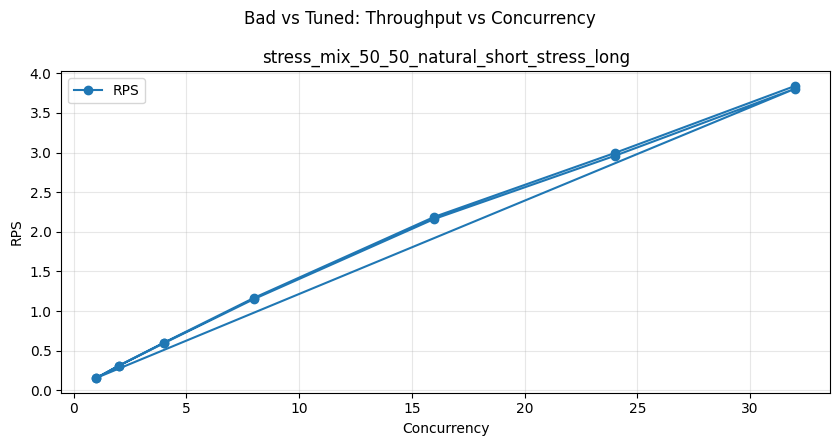

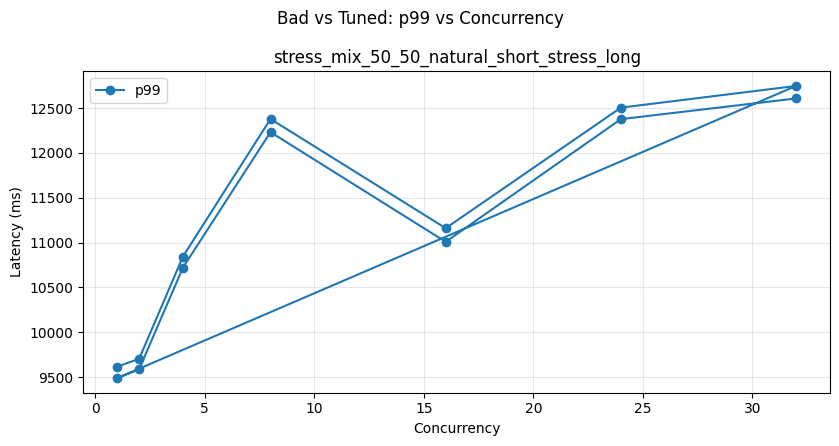

In [11]:
comparison_rows = [row for row in summary_rows if row.get('experiment_family') == 'bad_vs_tuned_server_config']
comparison_rows = sorted(comparison_rows, key=lambda row: (str(row.get('server_config_id')), float(row.get('concurrency') or 0)))
if pd is not None:
    display(pd.DataFrame(comparison_rows))
else:
    print(comparison_rows)

plot_metric(
    comparison_rows,
    'Bad vs Tuned: Throughput vs Concurrency',
    [('throughput_rps', 'RPS')],
    'RPS',
)
plot_metric(
    comparison_rows,
    'Bad vs Tuned: p99 vs Concurrency',
    [('latency_p99_ms', 'p99')],
    'Latency (ms)',
)


## Config Sweep Heatmaps

Heatmaps expose the search surface behind the tuned-config choice.

### How to interpret

- Throughput heatmap: where RPS plateaus or peaks across `max_num_batched_tokens` x `max_num_seqs`
- Short-p99 heatmap: where improved throughput starts paying more tail cost

### Observed surface shape

Best search throughput appears near:
- `max_num_batched_tokens=2048`
- `max_num_seqs=48`
- approximately `1.86 RPS` in the search workload

The surrounding region is competitive, indicating a relatively smooth surface rather than a fragile single-point optimum.

### Decision implication

Choose a near-knee tuned point with stable short-tail behavior, then monitor. Avoid over-optimizing for tiny RPS gains that may trade away reliability headroom.


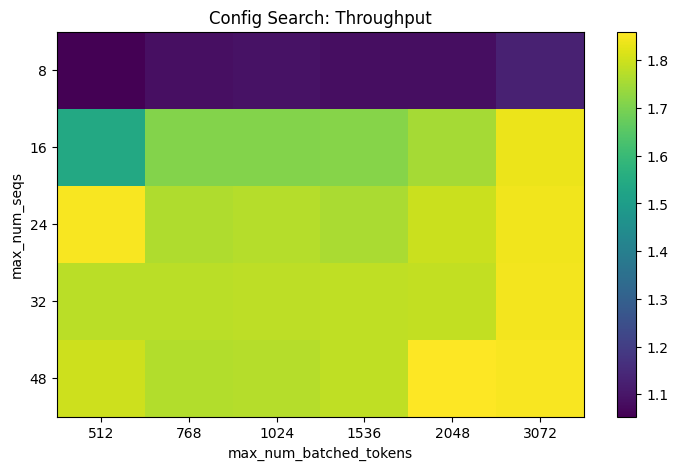

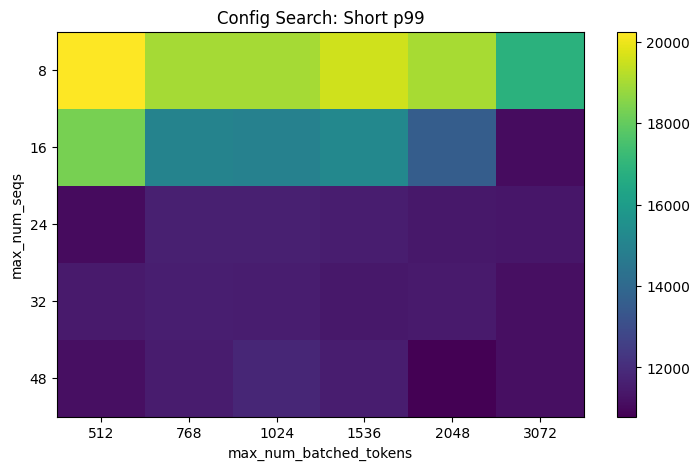

In [12]:
if config_search_rows:
    btoks = sorted({int(float(row.get('max_num_batched_tokens') or 0)) for row in config_search_rows})
    seqs = sorted({int(float(row.get('max_num_seqs') or 0)) for row in config_search_rows})

    def heatmap(value_key, title):
        matrix = []
        for seq in seqs:
            matrix_row = []
            for btok in btoks:
                value = next(
                    (
                        float(row.get(value_key) or 0.0)
                        for row in config_search_rows
                        if int(float(row.get('max_num_batched_tokens') or 0)) == btok and int(float(row.get('max_num_seqs') or 0)) == seq
                    ),
                    0.0,
                )
                matrix_row.append(value)
            matrix.append(matrix_row)
        plt.figure(figsize=(8.5, 5.0))
        plt.imshow(matrix, aspect='auto', cmap='viridis')
        plt.title(title)
        plt.xticks(range(len(btoks)), btoks)
        plt.yticks(range(len(seqs)), seqs)
        plt.xlabel('max_num_batched_tokens')
        plt.ylabel('max_num_seqs')
        plt.colorbar()
        plt.show()

    heatmap('throughput_rps', 'Config Search: Throughput')
    heatmap('short_p99_ms', 'Config Search: Short p99')
else:
    print('No config-search rows were found in the bundle.')


## Correctness Spot Checks

Performance conclusions are valid only if the output contract remains intact.

### What is checked

- JSON parse pass rate
- schema validation pass rate
- sampled field-level indicators where available

### Run-specific reading

Healthy experiment families generally preserve parse/schema behavior in sampled responses. The major correctness degradation signal in this benchmark run is tied to failure-dominated stress points where requests do not return usable outputs, not to a newly introduced formatting regression in successful runs.

### Why this distinction matters

If failures are infrastructure/scheduling-related, the mitigation is operational (concurrency caps, config, retry strategy, load shaping), not a claim that model semantics suddenly collapsed under normal serving.

So this section should be read as a contract-preservation check for successful paths plus a reliability warning for failed stress paths.


In [13]:
if pd is not None:
    display(pd.DataFrame(correctness_rows))
else:
    print(correctness_rows)

if correctness_rows and Markdown is not None:
    best_schema = max(correctness_rows, key=lambda row: float(row.get('schema_validation_pass_rate') or 0.0))
    display(Markdown(
        f"**Highest sampled schema-pass run:** `{best_schema.get('experiment_id')}` with "
        f"schema-pass rate `{best_schema.get('schema_validation_pass_rate'):.4f}` and "
        f"JSON parse rate `{best_schema.get('json_parse_pass_rate'):.4f}`."
    ))


,categorical_exact_match,experiment_id,json_parse_pass_rate,sample_size_actual,sample_size_requested,schema_validation_pass_rate,warnings
0,"{'customer.plan_tier': 0.8333333333333334, 'is...",smoke_single_stage-default-smoke_stratified-c1,1.0,30,128,1.0,[]
1,"{'customer.plan_tier': 0.8666666666666667, 'is...",smoke_single_stage-default-smoke_stratified-c4,1.0,30,128,1.0,[]
2,"{'customer.plan_tier': 0.6328125, 'issue_categ...",mixed_workload_baseline_sweep-default-natural_...,1.0,128,128,1.0,[]
3,"{'customer.plan_tier': 0.6484375, 'issue_categ...",mixed_workload_baseline_sweep-default-natural_...,1.0,128,128,1.0,[]
4,"{'customer.plan_tier': 0.6484375, 'issue_categ...",mixed_workload_baseline_sweep-default-natural_...,1.0,128,128,1.0,[]
...,...,...,...,...,...,...,...
69,"{'customer.plan_tier': 0.703125, 'issue_catego...",bad_vs_tuned_server_config-tuned-config-stress...,1.0,128,128,1.0,[]
70,"{'customer.plan_tier': 0.65625, 'issue_categor...",bad_vs_tuned_server_config-tuned-config-stress...,1.0,128,128,1.0,[]
71,"{'customer.plan_tier': 0.625, 'issue_category'...",bad_vs_tuned_server_config-tuned-config-stress...,1.0,128,128,1.0,[]
72,"{'customer.plan_tier': 0.6796875, 'issue_categ...",bad_vs_tuned_server_config-tuned-config-stress...,1.0,128,128,1.0,[]


**Highest sampled schema-pass run:** `smoke_single_stage-default-smoke_stratified-c1` with schema-pass rate `1.0000` and JSON parse rate `1.0000`.

## Deployment Recommendation And Conclusions

This section translates evidence into deployment guidance.

## Recommended default

- serve promoted LoRA-backed target (`base_plus_lora`)
- keep tuned scheduler config as default
- use `c8` region as practical knee for natural mixed workloads on this serving tier

## Key findings from this run

1. Throughput scales to a knee, then saturates while latency continues to rise.
2. p99 expands meaningfully beyond knee, with clear tail-risk growth.
3. Prompt-length interference is real: short requests are affected by long-request queue pressure.
4. Stress-heavy high concurrency surfaces reliability failures (not healthy capacity gains).
5. Tuning improves the operating point modestly and consistently.

## Operational policy implied by the data

- keep production concurrency conservative around the pre-saturation region
- monitor p99 and failure rate jointly, not throughput alone
- separate stress-failure diagnostics from normal-service capacity claims
- repeat this benchmark when hardware tier or scheduler strategy changes

## Final interpretation

For this repo stage, the benchmark supports a practical production posture: stable LoRA-backed serving with tuned scheduling and explicit tail/reliability guardrails. The results are useful precisely because they are honest about both gains and limits.
